In [1]:
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data, Dataset, DataLoader
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from tqdm import tqdm

from typing import Callable, Optional, Union
from torch import Tensor
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.dense.linear import Linear
from torch_geometric.nn.inits import reset
from torch_geometric.typing import (
    Adj,
    OptPairTensor,
    OptTensor,
    Size,
    SparseTensor
)
from torch_geometric.utils import spmm

c:\user\projects\thesis\new_repo\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Defining the model classes

In [2]:
class GINConv(MessagePassing):
    r"""The graph isomorphism operator from the `"How Powerful are
    Graph Neural Networks?" <https://arxiv.org/abs/1810.00826>`_ paper.

    .. math::
        \mathbf{x}^{\prime}_i = h_{\mathbf{\Theta}} \left( (1 + \epsilon) \cdot
        \mathbf{x}_i + \sum_{j \in \mathcal{N}(i)} \mathbf{x}_j \right)

    or

    .. math::
        \mathbf{X}^{\prime} = h_{\mathbf{\Theta}} \left( \left( \mathbf{A} +
        (1 + \epsilon) \cdot \mathbf{I} \right) \cdot \mathbf{X} \right),

    here :math:`h_{\mathbf{\Theta}}` denotes a neural network, *.i.e.* an MLP.

    Args:
        nn (torch.nn.Module): A neural network :math:`h_{\mathbf{\Theta}}` that
            maps node features :obj:`x` of shape :obj:`[-1, in_channels]` to
            shape :obj:`[-1, out_channels]`, *e.g.*, defined by
            :class:`torch.nn.Sequential`.
        eps (float, optional): (Initial) :math:`\epsilon`-value.
            (default: :obj:`0.`)
        train_eps (bool, optional): If set to :obj:`True`, :math:`\epsilon`
            will be a trainable parameter. (default: :obj:`False`)
        **kwargs (optional): Additional arguments of
            :class:`torch_geometric.nn.conv.MessagePassing`.

    Shapes:
        - **input:**
          node features :math:`(|\mathcal{V}|, F_{in})` or
          :math:`((|\mathcal{V_s}|, F_{s}), (|\mathcal{V_t}|, F_{t}))`
          if bipartite,
          edge indices :math:`(2, |\mathcal{E}|)`
        - **output:** node features :math:`(|\mathcal{V}|, F_{out})` or
          :math:`(|\mathcal{V}_t|, F_{out})` if bipartite
    """
    def __init__(self, nn: Callable, eps: float = 0., train_eps: bool = False,
                 **kwargs):
        kwargs.setdefault('aggr', 'add')
        super().__init__(**kwargs)
        self.nn = nn
        self.initial_eps = eps
        if train_eps:
            self.eps = torch.nn.Parameter(torch.empty(1))
        else:
            self.register_buffer('eps', torch.empty(1))
        self.reset_parameters()

    def reset_parameters(self):
        super().reset_parameters()
        reset(self.nn)
        self.eps.data.fill_(self.initial_eps)

    def forward(
        self,
        x: Union[Tensor, OptPairTensor],
        edge_index: Adj,
        edge_attr: OptTensor = None,
        edge_weight: OptTensor = None,
        size: Size = None,
    ) -> Tensor:

        if isinstance(x, Tensor):
            x = (x, x)

        # propagate_type: (x: OptPairTensor, edge_weight: OptTensor)
        out = self.propagate(edge_index, x=x, edge_weight=edge_weight, size=size)

        x_r = x[1]
        if x_r is not None:
            out = out + (1 + self.eps) * x_r

        return self.nn(out)

    def message(self, x_j: Tensor, edge_weight: OptTensor) -> Tensor:
        # Apply edge weights if provided
        if edge_weight is not None:
            # Handle edge weights that are 1D (need to reshape)
            if edge_weight.dim() == 1:
                edge_weight = edge_weight.view(-1, 1)
            
            # Apply weight to messages
            return x_j * edge_weight
        return x_j

    def message_and_aggregate(self, adj_t: Adj, x: OptPairTensor) -> Tensor:
        # Note: This method won't support edge weights in its current form
        # For edge weights, the regular message+aggregate pipeline will be used
        if isinstance(adj_t, SparseTensor):
            adj_t = adj_t.set_value(None, layout=None)
        return spmm(adj_t, x[0], reduce=self.aggr)

    def __repr__(self) -> str:
        return f'{self.__class__.__name__}(nn={self.nn})'


In [3]:
# explicit_join_model/model.py
class CostGNNv2(nn.Module):
	def __init__(self, node_feature_dim, hidden_dim):
		super(CostGNNv2, self).__init__()
		
		# Projection for first residual connection
		self.projection = nn.Linear(node_feature_dim, hidden_dim)
		
		# Define MLPs for GINConv layers
		self.mlp1 = nn.Sequential(
			nn.Linear(node_feature_dim, hidden_dim),
			nn.ReLU(),
			nn.Linear(hidden_dim, hidden_dim)
		)
		
		self.mlp2 = nn.Sequential(
			nn.Linear(hidden_dim, hidden_dim),
			nn.ReLU(),
			nn.Linear(hidden_dim, hidden_dim)
		)
		
		self.mlp3 = nn.Sequential(
			nn.Linear(hidden_dim, hidden_dim),
			nn.ReLU(),
			nn.Linear(hidden_dim, hidden_dim)
		)
		
		# GINConv layers for message passing
		self.conv1 = GINConv(self.mlp1)
		self.conv2 = GINConv(self.mlp2)
		self.conv3 = GINConv(self.mlp3)
		
		# Layer normalization after each residual connection
		self.layer_norm1 = nn.LayerNorm(hidden_dim)
		self.layer_norm2 = nn.LayerNorm(hidden_dim)
		self.layer_norm3 = nn.LayerNorm(hidden_dim)
		
		# Additional FC layers with nonlinearities
		self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
		self.fc2 = nn.Linear(hidden_dim // 2, 1)
		
		# Dropout for regularization
		self.dropout = nn.Dropout(0.2)

	def forward(self, x, edge_index, edge_weight=None, batch=None):
		# For the first layer, project input to match hidden_dim for residual
		residual = self.projection(x)
		
		# First message passing layer
		if edge_weight is not None:
			x = self.conv1(x, edge_index, edge_weight=edge_weight)
		else:
			x = self.conv1(x, edge_index)
		
		# Add residual and apply layer norm
		x = x + residual
		x = self.layer_norm1(x)
		x = F.relu(x)
		x = self.dropout(x)
		
		# Second message passing layer with residual
		residual = x
		if edge_weight is not None:
			x = self.conv2(x, edge_index, edge_weight=edge_weight)
		else:
			x = self.conv2(x, edge_index)
		
		# Add residual and apply layer norm
		x = x + residual
		x = self.layer_norm2(x)
		x = F.relu(x)
		x = self.dropout(x)
		
		# Third message passing layer with residual
		residual = x
		if edge_weight is not None:
			x = self.conv3(x, edge_index, edge_weight=edge_weight)
		else:
			x = self.conv3(x, edge_index)
		
		# Add residual and apply layer norm
		x = x + residual
		x = self.layer_norm3(x)
		x = F.relu(x)

		# Global pooling
		if batch is not None:
			x = scatter(x, batch, dim=0, reduce='add')
		else:
			x = torch.sum(x, dim=0)
		
		# Apply FC layers with nonlinearities
		x = self.fc1(x)
		x = F.relu(x)
		x = self.dropout(x)
		cost = torch.abs(self.fc2(x))

		return torch.squeeze(cost)

## Implementing the approach

### TorchIMLE

In [4]:
from torch import Tensor
from abc import ABC, abstractmethod

import logging

logger = logging.getLogger(__name__)


class BaseTargetDistribution(ABC):
    def __init__(self):
        super().__init__()

    @abstractmethod
    def params(self,
               theta: Tensor,
               dy: Tensor) -> Tensor:
        raise NotImplementedError


class TargetDistribution(BaseTargetDistribution):
    r"""
    Creates a generator of target distributions parameterized by :attr:`alpha` and :attr:`beta`.

    Example::

        >>> import torch
        >>> target_distribution = TargetDistribution(alpha=1.0, beta=1.0)
        >>> target_distribution.params(theta=torch.tensor([1.0]), dy=torch.tensor([1.0]))
        tensor([2.])

    Args:
        alpha (float): weight of the initial distribution parameters theta
        beta (float): weight of the downstream gradient dy
    """
    def __init__(self,
                 alpha: float = 1.0,
                 beta: float = 1.0):
        super().__init__()
        self.alpha = alpha
        self.beta = beta

    def params(self,
               theta: Tensor,
               dy: Tensor) -> Tensor:
        theta_prime = self.alpha * theta - self.beta * dy
        return theta_prime

In [5]:
import math

import torch
from torch import Tensor, Size
from torch.distributions.gamma import Gamma

from abc import ABC, abstractmethod

from typing import Optional

import logging

logger = logging.getLogger(__name__)


class BaseNoiseDistribution(ABC):
    def __init__(self):
        super().__init__()

    @abstractmethod
    def sample(self,
               shape: Size) -> Tensor:
        raise NotImplementedError


class SumOfGammaNoiseDistribution(BaseNoiseDistribution):
    r"""
    Creates a generator of samples for the Sum-of-Gamma distribution [1], parameterized
    by :attr:`k`, :attr:`nb_iterations`, and :attr:`device`.

    [1] Mathias Niepert, Pasquale Minervini, Luca Franceschi - Implicit MLE: Backpropagating Through Discrete
    Exponential Family Distributions. NeurIPS 2021 (https://arxiv.org/abs/2106.01798)

    Example::

        >>> import torch
        >>> noise_distribution = SumOfGammaNoiseDistribution(k=5, nb_iterations=100)
        >>> noise_distribution.sample(torch.Size([5]))
        tensor([ 0.2504,  0.0112,  0.5466,  0.0051, -0.1497])

    Args:
        k (float): k parameter -- see [1] for more details.
        nb_iterations (int): number of iterations for estimating the sample.
        device (torch.devicde): device where to store samples.
    """
    def __init__(self,
                 k: float,
                 nb_iterations: int = 10,
                 device: Optional[torch.device] = None):
        super().__init__()
        self.k = k
        self.nb_iterations = nb_iterations
        self.device = device

    def sample(self,
               shape: Size) -> Tensor:
        samples = torch.zeros(size=shape, device=self.device)
        for i in range(1, self.nb_iterations + 1):
            concentration = torch.tensor(1. / self.k, device=self.device)
            rate = torch.tensor(i / self.k, device=self.device)

            gamma = Gamma(concentration=concentration, rate=rate)
            samples = samples + gamma.sample(sample_shape=shape).to(self.device)
        samples = (samples - math.log(self.nb_iterations)) / self.k
        return samples.to(self.device)

In [6]:
import functools

import torch
from torch import Tensor

from typing import Callable, Optional

import logging

logger = logging.getLogger(__name__)


def imle(function: Callable[[Tensor], Tensor] = None,
         target_distribution: Optional[BaseTargetDistribution] = None,
         noise_distribution: Optional[BaseNoiseDistribution] = None,
         nb_samples: int = 1,
         input_noise_temperature: float = 1.0,
         target_noise_temperature: float = 1.0):
    r"""Turns a black-box combinatorial solver in an Exponential Family distribution via Perturb-and-MAP and I-MLE [1].

    The input function (solver) needs to return the solution to the problem of finding a MAP state for a constrained
    exponential family distribution -- this is the case for most black-box combinatorial solvers [2]. If this condition
    is violated though, the result would not hold and there is no guarantee on the validity of the obtained gradients.

    This function can be used directly or as a decorator.

    [1] Mathias Niepert, Pasquale Minervini, Luca Franceschi - Implicit MLE: Backpropagating Through Discrete
    Exponential Family Distributions. NeurIPS 2021 (https://arxiv.org/abs/2106.01798)
    [2] Marin Vlastelica, Anselm Paulus, Vít Musil, Georg Martius, Michal Rolínek - Differentiation of Blackbox
    Combinatorial Solvers. ICLR 2020 (https://arxiv.org/abs/1912.02175)

    Example::

        >>> from imle.wrapper import imle
        >>> from imle.target import TargetDistribution
        >>> from imle.noise import SumOfGammaNoiseDistribution
        >>> target_distribution = TargetDistribution(alpha=0.0, beta=10.0)
        >>> noise_distribution = SumOfGammaNoiseDistribution(k=21, nb_iterations=100)
        >>> @imle(target_distribution=target_distribution, noise_distribution=noise_distribution, nb_samples=100,
        >>>       input_noise_temperature=input_noise_temperature, target_noise_temperature=5.0)
        >>> def imle_solver(weights_batch: Tensor) -> Tensor:
        >>>     return torch_solver(weights_batch)

    Args:
        function (Callable[[Tensor], Tensor]): black-box combinatorial solver
        target_distribution (Optional[BaseTargetDistribution]): factory for target distributions
        noise_distribution (Optional[BaseNoiseDistribution]): noise distribution
        nb_samples (int): number of noise sammples
        input_noise_temperature (float): noise temperature for the input distribution
        target_noise_temperature (float): noise temperature for the target distribution
    """
    if target_distribution is None:
        target_distribution = TargetDistribution(alpha=1.0, beta=1.0)

    if function is None:
        return functools.partial(imle,
                                 target_distribution=target_distribution,
                                 noise_distribution=noise_distribution,
                                 nb_samples=nb_samples,
                                 input_noise_temperature=input_noise_temperature,
                                 target_noise_temperature=target_noise_temperature)

    @functools.wraps(function)
    def wrapper(input: Tensor, *args):
        class WrappedFunc(torch.autograd.Function):

            @staticmethod
            def forward(ctx, input: Tensor, *args):
                # [BATCH_SIZE, ...]
                input_shape = input.shape

                batch_size = input_shape[0]
                instance_shape = input_shape[1:]

                # [BATCH_SIZE, N_SAMPLES, ...]
                perturbed_input_shape = [batch_size, nb_samples] + list(instance_shape)

                if noise_distribution is None:
                    noise = torch.zeros(size=perturbed_input_shape)
                else:
                    noise = noise_distribution.sample(shape=torch.Size(perturbed_input_shape))

                input_noise = noise * input_noise_temperature

                # [BATCH_SIZE, N_SAMPLES, ...]
                perturbed_input_3d = input.view(batch_size, 1, -1).repeat(1, nb_samples, 1).view(perturbed_input_shape)
                perturbed_input_3d = perturbed_input_3d + input_noise

                # [BATCH_SIZE * N_SAMPLES, ...]
                perturbed_input_2d = perturbed_input_3d.view([-1] + perturbed_input_shape[2:])
                perturbed_input_2d_shape = perturbed_input_2d.shape

                # [BATCH_SIZE * N_SAMPLES, ...]
                perturbed_output = function(perturbed_input_2d)
                # [BATCH_SIZE, N_SAMPLES, ...]
                perturbed_output = perturbed_output.view(perturbed_input_shape)

                ctx.save_for_backward(input, noise, perturbed_output)

                # [BATCH_SIZE * N_SAMPLES, ...]
                res = perturbed_output.view(perturbed_input_2d_shape)
                return res

            @staticmethod
            def backward(ctx, dy):
                # input: [BATCH_SIZE, ...]
                # noise: [BATCH_SIZE, N_SAMPLES, ...]
                # perturbed_output_3d: # [BATCH_SIZE, N_SAMPLES, ...]
                input, noise, perturbed_output_3d = ctx.saved_variables

                input_shape = input.shape
                batch_size = input_shape[0]

                # dy is [BATCH_SIZE * N_SAMPLES, ...]
                dy_shape = dy.shape
                # noise is [BATCH_SIZE, N_SAMPLES, ...]
                noise_shape = noise.shape

                # [BATCH_SIZE * NB_SAMPLES, ...]
                input_2d = input.view(batch_size, 1, -1).repeat(1, nb_samples, 1).view(dy_shape)
                target_input_2d = target_distribution.params(input_2d, dy)

                # [BATCH_SIZE, NB_SAMPLES, ...]
                target_input_3d = target_input_2d.view(noise_shape)

                # [BATCH_SIZE, NB_SAMPLES, ...]
                target_noise = noise * target_noise_temperature

                # [BATCH_SIZE, N_SAMPLES, ...]
                perturbed_target_input_3d = target_input_3d + target_noise

                # [BATCH_SIZE * N_SAMPLES, ...]
                perturbed_target_input_2d = perturbed_target_input_3d.view(dy_shape)

                # [BATCH_SIZE * N_SAMPLES, ...]
                target_output_2d = function(perturbed_target_input_2d)

                # [BATCH_SIZE, N_SAMPLES, ...]
                target_output_3d = target_output_2d.view(noise_shape)

                # [BATCH_SIZE, ...]
                gradient = (perturbed_output_3d - target_output_3d)
                gradient = gradient.mean(axis=1)
                return gradient

        return WrappedFunc.apply(input, *args)
    return wrapper

### Custom solver

In [40]:
def cont_adj2disc_adj(adj_matrix: Tensor) -> Tensor:
	adj_matrix = adj_matrix * adj_matrix
	n = adj_matrix.shape[0]
	# First: compute the maximum spanning tree

	# leafness = np.sum(adj_matrix, axis=0) - np.sum(adj_matrix, axis=1)
	# number_outgoing = -np.sum(adj_matrix, axis=1)
	# leaf_top = sorted(
	# 	range(n),
	# 	key = lambda i: (leafness[i], number_outgoing[i])
	# )

	incoming = torch.sum(adj_matrix, dim=0)
	outgoing = torch.sum(adj_matrix, dim=1)
	leaf_top = torch.argsort( # The first indexes is more likely to be a leaf
		incoming - outgoing)
	
	tree_nodes = {int(torch.argmin(outgoing))} # Start with the last one, which is most likely not a leaf
	spanning_tree = torch.zeros_like(adj_matrix)
	for i in leaf_top:
		i = i.item()
		if i in tree_nodes:
			continue

		# Find the node with the maximum weight edge from i
		path = {i}
		while True:
			next_node = max(
				range(n),
				key=lambda j: adj_matrix[i, j].item() if j not in path else -1
			)
			path.add(next_node)
			spanning_tree[i, next_node] = 1
			if next_node in tree_nodes:
				break

			i = next_node
		
		tree_nodes |= path
	
	return spanning_tree


cont_adj2disc_adj(torch.tensor([
	[0.        , 0.85176577, 0.05586463, 0.        , 0.        ],
	[0.        , 0.        , 0.        , 0.41488738, 1.        ],
	[0.        , 0.38237081, 0.        , 0.        , 0.01559764],
	[0.37597381, 0.1763692 , 0.04406938, 0.06162347, 1.        ],
	[0.20896545, 0.54737867, 0.75436813, 0.        , 0.26826372]
]))

tensor([[0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0.]])

In [164]:
from dataclasses import dataclass
from typing import Union, Optional, Callable

import re
import requests
import numpy as np


@dataclass
class Entity:
	name: str

	def __post_init__(self):
		self.is_variable = self.name.startswith("?")
	
	def __str__(self) -> str:
		return self.name
	
	def __hash__(self):
		return hash(self.name)
			

@dataclass
class Triple:
	s: Entity
	p: Entity
	o: Entity

	def __post_init__(self):
		self.variables = {
			var for var in [self.s, self.p, self.o]
				if var.is_variable
		}
	
	@staticmethod
	def from_triple_str(triple_str: str) -> "Triple":
		parts = triple_str.split()
		if len(parts) != 3:
			raise ValueError(f"Invalid triple string: {triple_str}")
		
		return Triple(*(Entity(p) for p in parts))

	def where_body(self) -> str:
		return f"{self.s} {self.p} {self.o}."
	
	def json(self) -> Union[str, list]:
		return self.where_body()
	
	def to_set(self) -> frozenset:
		return frozenset([self.json()])
	
	def get_cost(self) -> int:
		return 0



@dataclass
class Join:
	left: Union[Triple, "Join"]
	right: Union[Triple, "Join"]

	def __post_init__(self):
		self.variables = {
			*self.left.variables,
			*self.right.variables
		}
	
	def where_body(self) -> str:
		return f"{self.left.where_body()} {self.right.where_body()}"
	
	def __str__(self) -> str:
		return f"""
			SELECT {', '.join(str(var) for var in self.variables)}
			FROM <lubm>
			WHERE {{
				{self.where_body()}
			}}
		"""

	def json(self) -> Union[str, list]:
		return [self.left.json(), self.right.json()]
	
	def get_cost(self) -> int:
		query = f"""
			SELECT COUNT(*) AS ?count
			FROM <lubm>
			WHERE {{ 
				{self.where_body()}	
			}}
		"""
		res = requests.get(
			"http://127.0.0.1:8890/sparql/",
			params={
				"query": query,
				"format": "csv",
			},
		).text
		
		m = re.match(r'"count"\n(\d+)\n', res)
		
		if not m:
			num_trials = 3
			while not m and num_trials > 0:
				res = requests.get(
					"http://127.0.0.1:8890/sparql/",
					params={
						"query": query,
						"format": "csv",
					},
				).text
				m = re.match(r'"count"\n(\d+)\n', res)
				num_trials -= 1

			if not m:
				print("Error in the following query:", query)
				raise RuntimeError("Query failed")

		self_cardinality = int(m.group(1))

		left_cardinality = self.left.get_cost()
		right_cardinality = self.right.get_cost()

		return self_cardinality + left_cardinality + right_cardinality
	
	def to_set(self) -> frozenset:
		return frozenset([
			self.left.to_set(),
			self.right.to_set()
		])
	

@dataclass
class Query:
	root: Join | Triple
	triples_num: int

	def __hash__(self) -> int:
		return hash(self.root.to_set())
	
	def __eq__(self, other: object) -> bool:
		if not isinstance(other, Query):
			return False
		
		return hash(self) == hash(other)


In [165]:
def adj2query_node(adj_matrix: Tensor, triples: list[str]) -> Query:
	class LinkedListTreeNode:
		def __init__(self, node_id, query_node: Union[Triple, "Join"]) -> None:
			self.node_id = node_id
			self.query_node = query_node
			self.successor: Optional['LinkedListTreeNode'] = None
			self.num_predecessors = 0

	n = adj_matrix.shape[0]
	if adj_matrix.shape != (n, n):
		raise ValueError("Adjacency matrix must be square.")
	
	nodes = {i: LinkedListTreeNode(i, Triple.from_triple_str(triples[i])) for i in range(n)}

	for i in range(n):
		for j in range(n):
			if not adj_matrix[i, j]:
				continue

			if nodes[i].successor is not None:
				raise ValueError("Found outgoing degree > 1.")

			nodes[i].successor = nodes[j]
			nodes[j].num_predecessors += 1
	
	joins_todo = n-1
	active_nodes = set(nodes.values())
	while joins_todo:
		leaf_nodes = {node for node in active_nodes if not node.num_predecessors}
		if not leaf_nodes:
			raise ValueError("No leaves found but multiple nodes remain. Check for cycles or disconnected components.")

		for leaf in leaf_nodes:
			if leaf.successor is None:
				continue

			successor = leaf.successor

			if any(leaf2.successor == successor for leaf2 in leaf_nodes if leaf2 != leaf):
				raise ValueError("Found multiple leaves with the same successor.")
			
			successor.query_node = Join(leaf.query_node, successor.query_node)
			successor.num_predecessors -= 1

			active_nodes.remove(leaf)
			joins_todo -= 1
	
	assert len(active_nodes) == 1, "More than one active node remaining after processing."
	return Query(
		active_nodes.pop().query_node,
		len(triples)
	)

In [152]:
import ray

# https://github.com/uclnlp/torch-imle/blob/b6678cd77a1a7218de6daa0f777ba6cf6cc5d9a6/annotation-cli.py#L40C1-L45C51
def maybe_parallelize(function):
	def new_func(arg_list):
		if ray.is_initialized():
			ray_fn = ray.remote(function)
			ret = ray.get([ray_fn.remote(arg) for arg in arg_list])
		else:
			ret = [function(arg) for arg in arg_list]
		
		return torch.stack(ret)
	
	return new_func


def imle_solver(adj: Tensor) -> Tensor:
	return imle(
		function=maybe_parallelize(
			cont_adj2disc_adj
		),
		target_distribution=TargetDistribution(alpha=1.0, beta=10.0),
		noise_distribution=SumOfGammaNoiseDistribution(k=len(adj)*2, nb_iterations=100),
		nb_samples=1,
		input_noise_temperature=5.,
		target_noise_temperature=5.
	)(adj[None, :, :])[0]

In [9]:
model = torch.load("./datasets/lubm/costgnnv2_implicit_balanced_q4.3.pkl").to("cpu")

In [10]:
import pickle

with open("./datasets/lubm/example_star_dataset_compact_implicit_join.pkl", "rb") as f:
	dataset = zip(*pickle.load(f))

In [11]:
dataset = [*zip(*dataset)]
dataset[0]

(['?s <http://example.org/6> <http://example.org/133531>.',
  '?s <http://example.org/3> ?o2.',
  '?s <http://example.org/8> <http://example.org/87855>.',
  '?s <http://example.org/2> ?o1.',
  '?s <http://example.org/6> ?o3.',
  '?s <http://example.org/6> <http://example.org/27303>.',
  '?s <http://example.org/4> <http://example.org/161290>.',
  '?s <http://example.org/7> <http://example.org/28>.'],
 Data(x=[8, 306], edge_index=[2, 7], y=[1]))

In [166]:
example_index = 1
example = dataset[example_index][1]
triples = dataset[example_index][0]
example

Data(x=[8, 306], edge_index=[2, 7], y=[1])

C:\Users\mario\AppData\Local\Temp\ipykernel_47076\1386724961.py:109: DeprecationWarning: 'saved_variables' is deprecated; use 'saved_tensors'
  input, noise, perturbed_output_3d = ctx.saved_variables


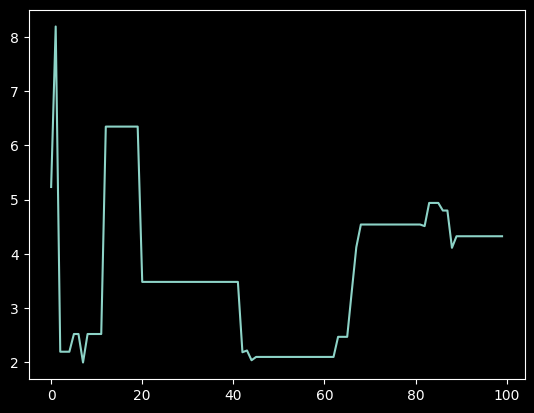

In [201]:
n = example.x.shape[0]
edge_index = torch.tensor(
    [(i, j) for i in range(n) for j in range(n) if i != j],
    dtype=torch.long
).t().contiguous()

m = edge_index.shape[1]
edge_weights = torch.full((m,), 1., requires_grad=True)

optimizer = optim.Adam([edge_weights], lr=100)

losses = []

def step():
	optimizer.zero_grad()
	
	adj = torch.zeros((n, n), dtype=torch.float)
	adj[edge_index[0], edge_index[1]] = edge_weights

	adj_disc = imle_solver(adj)
	edge_weights_disc = adj_disc[edge_index[0], edge_index[1]]

	loss = model(
		example.x,
		edge_index,
		edge_weight=edge_weights_disc,
	)
	losses.append(loss.item())

	loss.backward()
	optimizer.step()

for i in range(100):
	step()

plt.plot(losses)

In [203]:
adj = torch.zeros((n, n), dtype=torch.float)
adj[edge_index[0], edge_index[1]] = edge_weights

adj_disc = imle_solver(adj)
adj_disc

tensor([[0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0.]], grad_fn=<SelectBackward0>)

In [204]:
edge_weights_disc = adj_disc[edge_index[0], edge_index[1]]
torch.exp(model(
	example.x,
	edge_index,
	edge_weight=edge_weights_disc,
)).item()

75.39712524414062

In [159]:
example.y

tensor([432.])

In [140]:
edge_weights

tensor([   1.0000,   61.6828,    1.0000,    1.0000, -599.5506,  556.8887,
           1.0000,   61.6828,    1.0000,    1.0000,    1.0000, -599.5506,
         556.8887,    1.0000,    1.0000, -599.5506,    1.0000,    1.0000,
          61.6828,  556.8887,    1.0000,   61.6828,    1.0000,    1.0000,
           1.0000,    1.0000,  -59.6828,    1.0000,   61.6828,    1.0000,
           1.0000,    1.0000,    1.0000,  556.8887,    1.0000,    1.0000,
           1.0000,    1.0000, -599.5506,    1.0000,  556.8887,    1.0000,
          61.6828,    1.0000,    1.0000,    1.0000, -599.5506,    1.0000,
           1.0000,   61.6828, -599.5506,    1.0000,    1.0000,    1.0000,
           1.0000,  556.8887], requires_grad=True)

In [174]:
adj = torch.zeros((n, n), dtype=torch.float)
adj[example.edge_index[0], example.edge_index[1]] = 1.

In [205]:
adj2query_node(
    adj_disc,
    [triple[:-1] for triple in triples]
).root.get_cost()

70